
# 01 - Exploratory Analysis

## Evaluación 2 - Análisis exploratorio, visualizaciones y enfoque del modelado

Este notebook concentra el análisis exploratorio inicial solicitado para la Evaluación 2.  
Se trabaja con el dataset final generado por Kedro, por lo que los datos ya pasaron por las etapas de ingesta, limpieza, transformación y validación.

El notebook está dividido en tres bloques principales:

1. **EDA general:** revisión inicial del dataset final.
2. **EDA logístico:** análisis visual de patrones operacionales.
3. **Enfoque del modelado:** definición y justificación de las variables objetivo para Machine Learning.


1. DIMENSIONES DEL DATASET
Filas y columnas: (998, 56)

2. VARIABLES PRINCIPALES - DESCRIBE


,count,mean,std,min,25%,50%,75%,max
peso_kg,998.0,7860.699900,5340.718864,13.600000,3835.475000,7558.600000,11283.750000,40000.0
distancia_km,998.0,1026.657415,674.021421,29.600000,507.200000,919.300000,1492.800000,4000.0
velocidad_promedio_km_h,998.0,92.736315,59.472952,2.943396,40.136842,79.422222,155.914530,180.0
uso_capacidad_kg_recalculado,971.0,1.747518,1.626008,0.002410,0.498960,1.176100,2.510443,5.0
riesgo_operacional,971.0,1832.021294,2479.975768,0.355957,348.299907,925.223706,2279.954104,20000.0
riesgo_velocidad,998.0,119599.770365,126992.403801,91.833962,30397.719481,71619.702542,192456.000000,720000.0



3. TIPO DE CARGA



tipo_carga
refrigerada    252
frágil         190
perecible      189
general        187
peligrosa      180
Name: count, dtype: int64

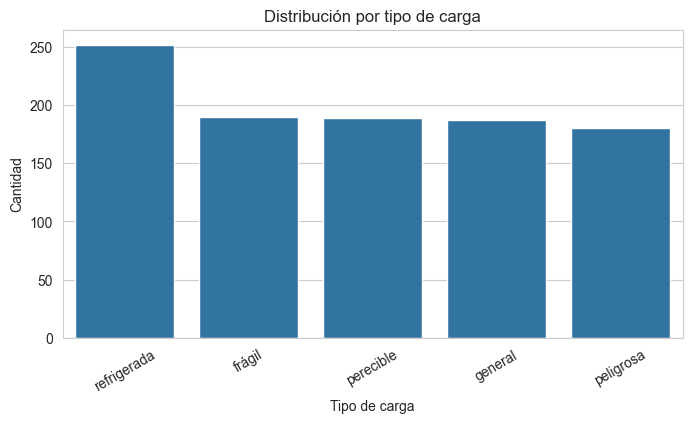


4. ESTADO DEL VEHÍCULO



estado_vehiculo
operativo            679
fuera de servicio    147
en mantención        145
Name: count, dtype: int64

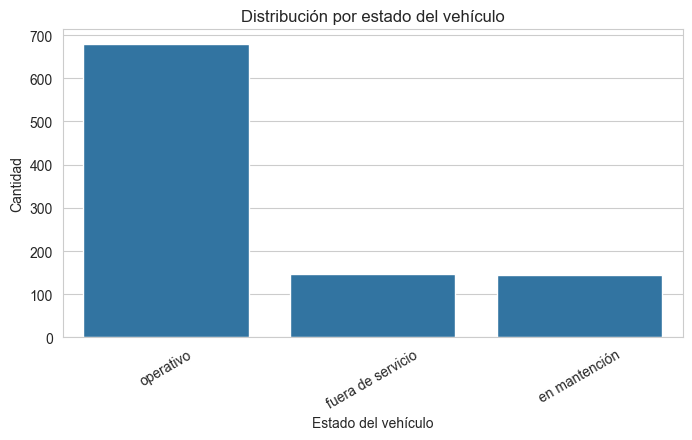


5. TIPO DE VÍA



tipo_via
urbana           396
autopista        269
ruta nacional    186
camino rural     147
Name: count, dtype: int64

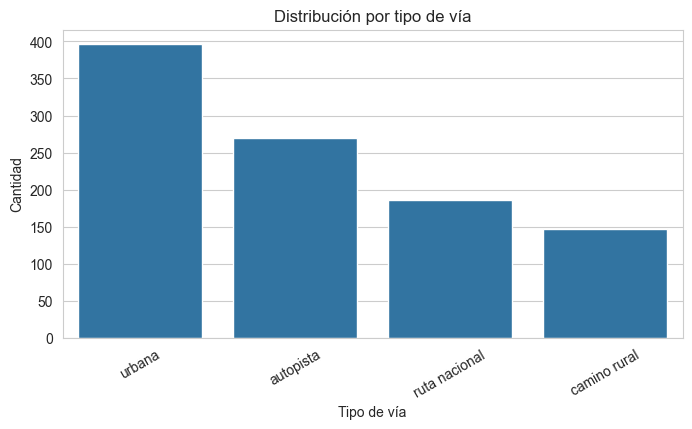


6. DISTRIBUCIÓN DE RIESGO OPERACIONAL


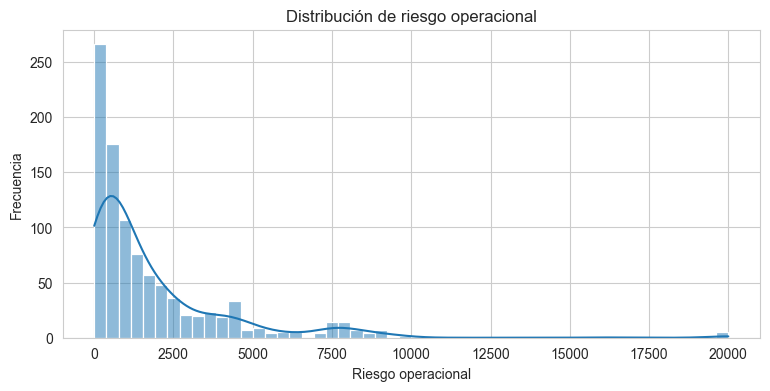


count      971.000000
mean      1832.021294
std       2479.975768
min          0.355957
25%        348.299907
50%        925.223706
75%       2279.954104
max      20000.000000
Name: riesgo_operacional, dtype: float64


7. VEHÍCULOS EXIGIDOS



vehiculo_exigido
1    562
0    436
Name: count, dtype: int64


vehiculo_exigido
1    56.312625
0    43.687375
Name: proportion, dtype: float64

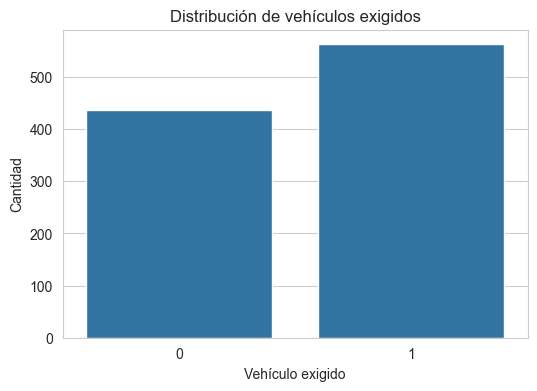


8. SOBRECARGA KG



sobrecarga_kg
1    528
0    470
Name: count, dtype: int64


sobrecarga_kg
1    52.905812
0    47.094188
Name: proportion, dtype: float64

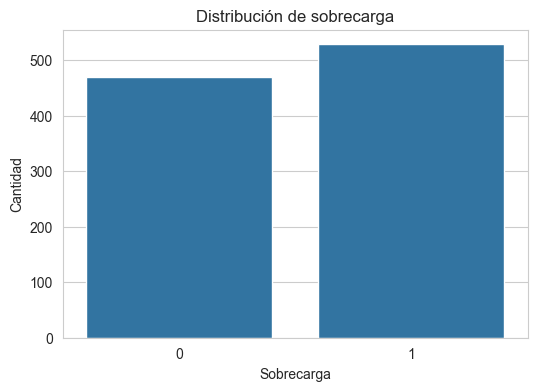


9. RUTAS LARGAS



ruta_larga
0    740
1    258
Name: count, dtype: int64


ruta_larga
0    74.148297
1    25.851703
Name: proportion, dtype: float64

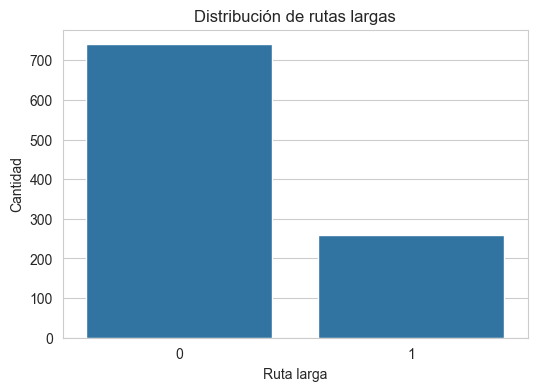


10. TOP 10 RUTAS MÁS EXIGENTES



id_ruta
60.0    8996.405263
9.0     4646.337566
49.0    4587.088523
36.0    4246.849992
69.0    3913.393512
41.0    3854.076985
34.0    3669.037023
19.0    3666.398027
16.0    3664.050768
58.0    3499.246184
Name: riesgo_operacional, dtype: float64

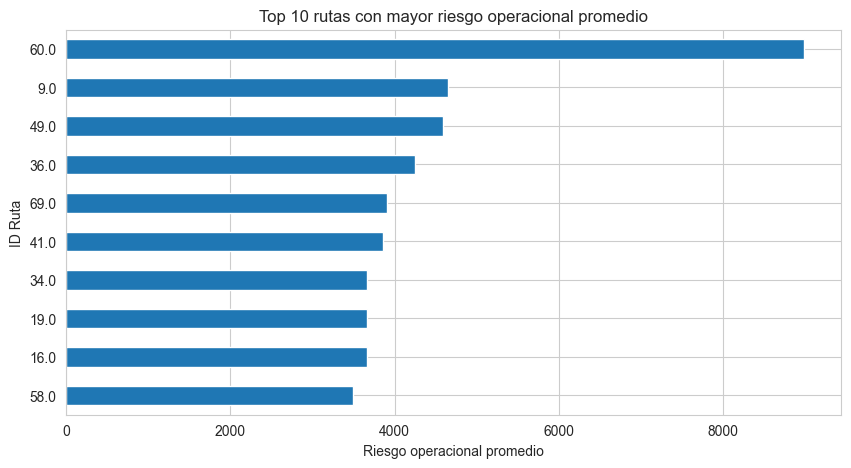


11. MAPA DE CORRELACIONES


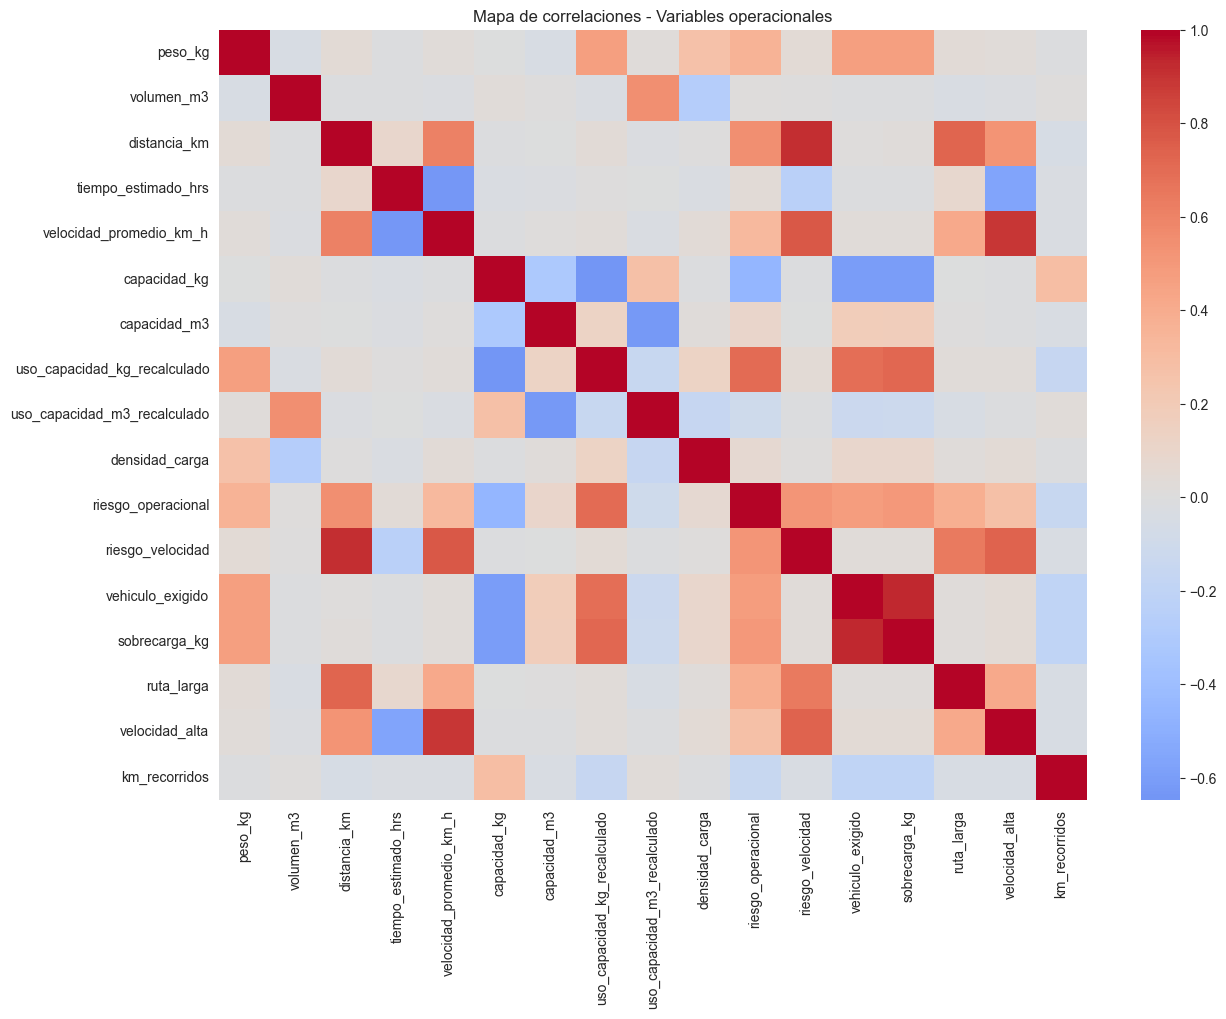


12. CORRELACIÓN CON RIESGO OPERACIONAL



riesgo_operacional              1.000000
uso_capacidad_kg_recalculado    0.709857
distancia_km                    0.547860
riesgo_velocidad                0.518194
sobrecarga_kg                   0.500248
vehiculo_exigido                0.479811
ruta_larga                      0.385355
peso_kg                         0.356387
velocidad_promedio_km_h         0.327477
velocidad_alta                  0.273212
capacidad_m3                    0.095255
densidad_carga                  0.069296
tiempo_estimado_hrs             0.036081
volumen_m3                      0.009718
uso_capacidad_m3_recalculado   -0.104740
km_recorridos                  -0.147929
capacidad_kg                   -0.448538
Name: riesgo_operacional, dtype: float64


13. RELACIONES VISUALES CON RIESGO OPERACIONAL


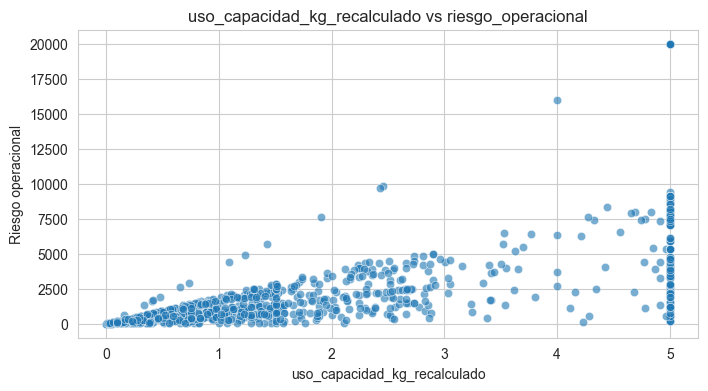

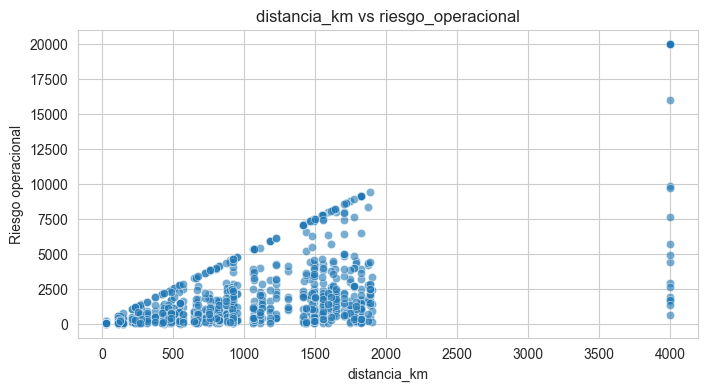

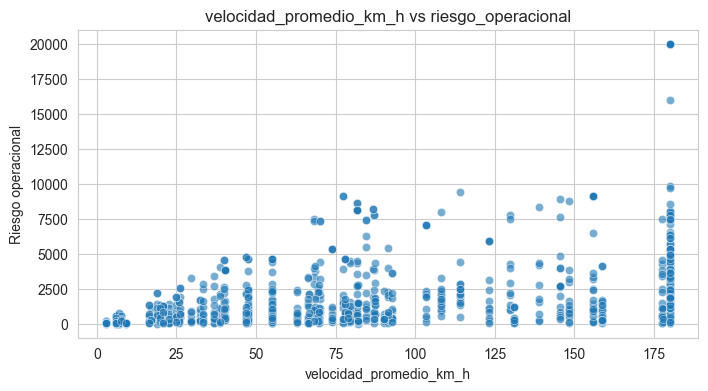

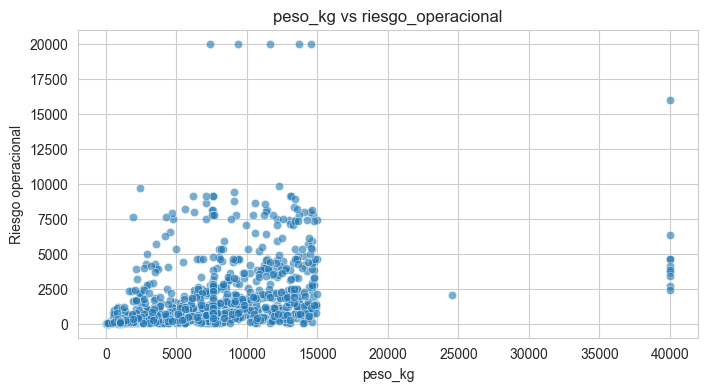

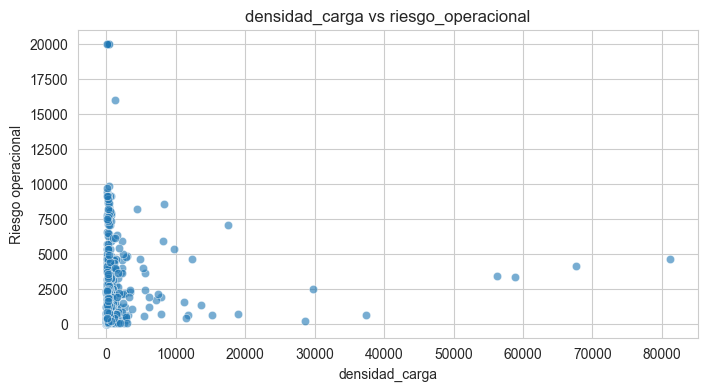

In [1]:
# ============================================================
# RESULTADOS PARA NOTEBOOK 01 - BUSINESS CONTEXT & EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# Cargar dataset V3
df_v3 = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

print("============================================================")
print("1. DIMENSIONES DEL DATASET")
print("============================================================")
print("Filas y columnas:", df_v3.shape)


print("\n============================================================")
print("2. VARIABLES PRINCIPALES - DESCRIBE")
print("============================================================")

variables = [
    "peso_kg",
    "distancia_km",
    "velocidad_promedio_km_h",
    "uso_capacidad_kg_recalculado",
    "riesgo_operacional",
    "riesgo_velocidad"
]

display(df_v3[variables].describe().T)


print("\n============================================================")
print("3. TIPO DE CARGA")
print("============================================================")
display(df_v3["tipo_carga"].value_counts())

plt.figure(figsize=(8,4))
sns.countplot(data=df_v3, x="tipo_carga", order=df_v3["tipo_carga"].value_counts().index)
plt.title("Distribución por tipo de carga")
plt.xlabel("Tipo de carga")
plt.ylabel("Cantidad")
plt.xticks(rotation=30)
plt.show()


print("\n============================================================")
print("4. ESTADO DEL VEHÍCULO")
print("============================================================")
display(df_v3["estado_vehiculo"].value_counts())

plt.figure(figsize=(8,4))
sns.countplot(data=df_v3, x="estado_vehiculo", order=df_v3["estado_vehiculo"].value_counts().index)
plt.title("Distribución por estado del vehículo")
plt.xlabel("Estado del vehículo")
plt.ylabel("Cantidad")
plt.xticks(rotation=30)
plt.show()


print("\n============================================================")
print("5. TIPO DE VÍA")
print("============================================================")
display(df_v3["tipo_via"].value_counts())

plt.figure(figsize=(8,4))
sns.countplot(data=df_v3, x="tipo_via", order=df_v3["tipo_via"].value_counts().index)
plt.title("Distribución por tipo de vía")
plt.xlabel("Tipo de vía")
plt.ylabel("Cantidad")
plt.xticks(rotation=30)
plt.show()


print("\n============================================================")
print("6. DISTRIBUCIÓN DE RIESGO OPERACIONAL")
print("============================================================")

plt.figure(figsize=(9,4))
sns.histplot(df_v3["riesgo_operacional"], kde=True)
plt.title("Distribución de riesgo operacional")
plt.xlabel("Riesgo operacional")
plt.ylabel("Frecuencia")
plt.show()

display(df_v3["riesgo_operacional"].describe())


print("\n============================================================")
print("7. VEHÍCULOS EXIGIDOS")
print("============================================================")
display(df_v3["vehiculo_exigido"].value_counts())
display(df_v3["vehiculo_exigido"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df_v3, x="vehiculo_exigido")
plt.title("Distribución de vehículos exigidos")
plt.xlabel("Vehículo exigido")
plt.ylabel("Cantidad")
plt.show()


print("\n============================================================")
print("8. SOBRECARGA KG")
print("============================================================")
display(df_v3["sobrecarga_kg"].value_counts())
display(df_v3["sobrecarga_kg"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df_v3, x="sobrecarga_kg")
plt.title("Distribución de sobrecarga")
plt.xlabel("Sobrecarga")
plt.ylabel("Cantidad")
plt.show()


print("\n============================================================")
print("9. RUTAS LARGAS")
print("============================================================")
display(df_v3["ruta_larga"].value_counts())
display(df_v3["ruta_larga"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df_v3, x="ruta_larga")
plt.title("Distribución de rutas largas")
plt.xlabel("Ruta larga")
plt.ylabel("Cantidad")
plt.show()


print("\n============================================================")
print("10. TOP 10 RUTAS MÁS EXIGENTES")
print("============================================================")

top_rutas = (
    df_v3
    .groupby("id_ruta")["riesgo_operacional"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

display(top_rutas)

plt.figure(figsize=(10,5))
top_rutas.sort_values().plot(kind="barh")
plt.title("Top 10 rutas con mayor riesgo operacional promedio")
plt.xlabel("Riesgo operacional promedio")
plt.ylabel("ID Ruta")
plt.show()


print("\n============================================================")
print("11. MAPA DE CORRELACIONES")
print("============================================================")

variables_corr = [
    "peso_kg",
    "volumen_m3",
    "distancia_km",
    "tiempo_estimado_hrs",
    "velocidad_promedio_km_h",
    "capacidad_kg",
    "capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",
    "densidad_carga",
    "riesgo_operacional",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "km_recorridos"
]

variables_corr = [col for col in variables_corr if col in df_v3.columns]

corr = df_v3[variables_corr].corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Mapa de correlaciones - Variables operacionales")
plt.show()


print("\n============================================================")
print("12. CORRELACIÓN CON RIESGO OPERACIONAL")
print("============================================================")

corr_riesgo = (
    corr["riesgo_operacional"]
    .sort_values(ascending=False)
)

display(corr_riesgo)


print("\n============================================================")
print("13. RELACIONES VISUALES CON RIESGO OPERACIONAL")
print("============================================================")

relaciones = [
    "uso_capacidad_kg_recalculado",
    "distancia_km",
    "velocidad_promedio_km_h",
    "peso_kg",
    "densidad_carga"
]

for col in relaciones:
    plt.figure(figsize=(8,4))
    sns.scatterplot(
        data=df_v3,
        x=col,
        y="riesgo_operacional",
        alpha=0.6
    )
    plt.title(f"{col} vs riesgo_operacional")
    plt.xlabel(col)
    plt.ylabel("Riesgo operacional")
    plt.show()

1. DATASET
Dimensiones: (998, 56)

2. UMBRALES USADOS
Percentil 75 dias_entrega: 7.0
Percentil 75 riesgo_operacional: 2279.9541040000004

3. DISTRIBUCIÓN DE TARGETS

--- tiene_incidencia ---
tiene_incidencia
0    834
1    164
Name: count, dtype: int64
tiene_incidencia
0    83.567134
1    16.432866
Name: proportion, dtype: float64


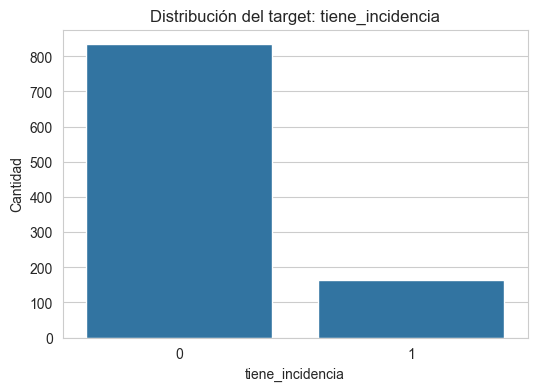


--- entrega_tardia ---
entrega_tardia
1    998
Name: count, dtype: int64
entrega_tardia
1    100.0
Name: proportion, dtype: float64


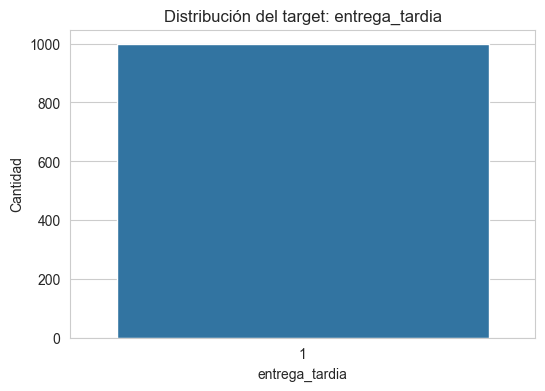


--- entrega_tardia_v3 ---
entrega_tardia_v3
1    925
0     73
Name: count, dtype: int64
entrega_tardia_v3
1    92.685371
0     7.314629
Name: proportion, dtype: float64


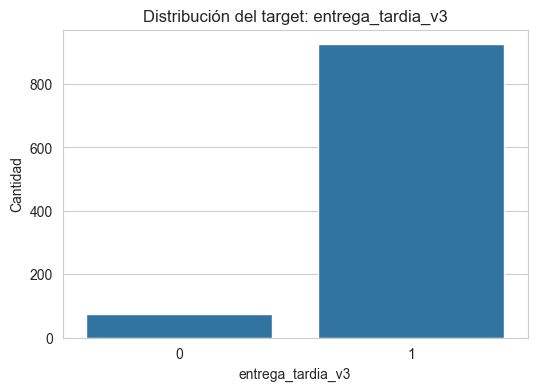


--- incidencia_multiclase ---
incidencia_multiclase
0    834
1    153
2     11
Name: count, dtype: int64
incidencia_multiclase
0    83.567134
1    15.330661
2     1.102204
Name: proportion, dtype: float64


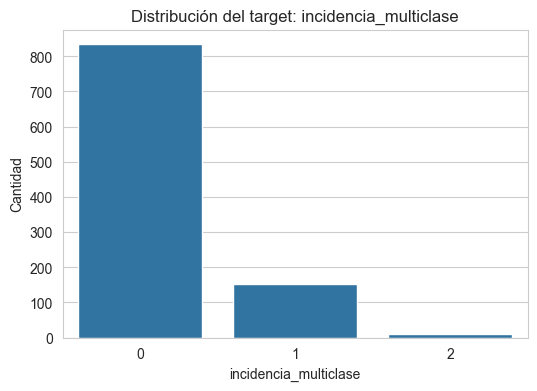


--- riesgo_operacional_alto ---
riesgo_operacional_alto
0    755
1    243
Name: count, dtype: int64
riesgo_operacional_alto
0    75.651303
1    24.348697
Name: proportion, dtype: float64


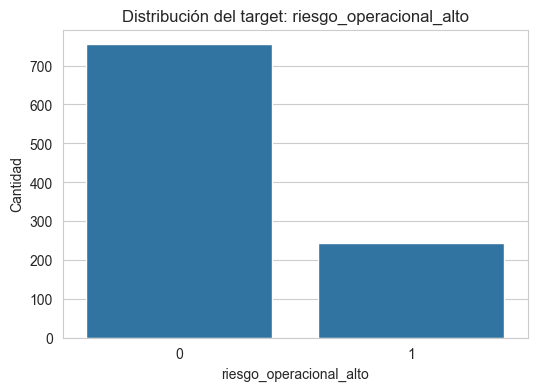


4. VARIABLES USADAS
Cantidad: 32
['distancia_km', 'tiempo_estimado_hrs', 'peso_kg', 'volumen_m3', 'capacidad_kg', 'capacidad_m3', 'velocidad_promedio_km_h', 'km_recorridos', 'tipo_via', 'tipo_carga', 'estado_vehiculo', 'tipo', 'uso_capacidad_kg', 'uso_capacidad_m3', 'uso_capacidad_kg_recalculado', 'uso_capacidad_m3_recalculado', 'antiguedad_vehiculo', 'densidad_carga', 'riesgo_velocidad', 'vehiculo_exigido', 'sobrecarga_kg', 'ruta_larga', 'velocidad_alta', 'vehiculo_riesgoso_estado', 'via_compleja', 'peso_kg_log', 'distancia_km_log', 'volumen_m3_log', 'velocidad_promedio_km_h_log', 'densidad_carga_log', 'riesgo_velocidad_log', 'km_recorridos_log']

5. RESULTADOS DE CLASIFICACIÓN


================ TARGET: tiene_incidencia ================


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
1,tiene_incidencia,Decision Tree,0.495,0.490927,0.160000,0.484848,0.240602
4,tiene_incidencia,SVM,0.585,0.496189,0.162162,0.363636,0.224299
5,tiene_incidencia,Gaussian NB,0.785,0.543005,0.272727,0.181818,0.218182
3,tiene_incidencia,KNN,0.805,0.530666,0.285714,0.121212,0.170213
0,tiene_incidencia,Logistic Regression,0.540,0.432771,0.116883,0.272727,0.163636
2,tiene_incidencia,Random Forest,0.800,0.503357,0.181818,0.060606,0.090909




================ TARGET: entrega_tardia ================


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:326                                                                                  │
│                                                                                                  │
│   323 for target in targets_clasificacion:                                                       │
│   324 │   print(f"\n\n================ TARGET: {target} ================")                       │
│   325 │                                                                                          │
│ ❱ 326 │   tabla, mejor_info = evaluar_clasificacion(target)                                      │
│   327 │                                                                                          │
│   328 │   display(tabla)                                                                         │
│   329                                                                                            │
│                                                                                                  │
│ in evaluar_clasificacion:264                                                                     │
│                                                                                                  │
│   261 │   │   │   ("modelo", modelo)                                                             │
│   262 │   │   ])                                                                                 │
│   263 │   │                                                                                      │
│ ❱ 264 │   │   pipe.fit(X_train, y_train)                                                         │
│   265 │   │   y_pred = pipe.predict(X_test)                                                      │
│   266 │   │                                                                                      │
│   267 │   │   promedio = "weighted" if y.nunique() > 2 else "binary"                             │
│                                                                                                  │
│ C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\sk │
│ learn\base.py:1365 in wrapper                                                                    │
│                                                                                                  │
│   1362 │   │   │   │   │   prefer_skip_nested_validation or global_skip_validation               │
│   1363 │   │   │   │   )                                                                         │
│   1364 │   │   │   ):                                                                            │
│ ❱ 1365 │   │   │   │   return fit_method(estimator, *args, **kwargs)                             │
│   1366 │   │                                                                                     │
│   1367 │   │   return wrapper                                                                    │
│   1368                                                                                           │
│                                                                                                  │
│ C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\sk │
│ learn\pipeline.py:663 in fit                                                                     │
│                                                                                                  │
│    660 │   │   │   │   │   step_params=routed_params[self.steps[-1][0]],                         │
│    661 │   │   │   │   │   all_params=params,                                                    │
│    662 │   │   │   │   )                                                                         │
│ ❱  663 │   │   │   │   self._final_estimator.fit(Xt, y, **last_step_params["fit"])               │
│    664 │   │                                               

In [1]:
# ============================================================
# RESULTADOS PARA 02_TARGET_SELECTION_AND_PROBLEM_DEFINITION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# ============================================================
# 1. CARGA DATASET
# ============================================================

df = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

print("============================================================")
print("1. DATASET")
print("============================================================")
print("Dimensiones:", df.shape)


# ============================================================
# 2. CREACIÓN / VERIFICACIÓN DE TARGETS
# ============================================================

# Target clasificación: incidencia binaria
df["tiene_incidencia"] = df["tiene_incidencia"].astype(int)

# Target entrega tardía original, si existe
if "entrega_tardia" in df.columns:
    df["entrega_tardia"] = df["entrega_tardia"].astype(int)
else:
    df["entrega_tardia"] = np.where(df["dias_entrega"] > 0, 1, 0)

# Target entrega tardía V3: criterio más razonable
percentil_entrega = df["dias_entrega"].quantile(0.75)

df["entrega_tardia_v3"] = np.where(
    df["dias_entrega"] >= percentil_entrega,
    1,
    0
)

# Target multiclase incidencias
df["incidencia_multiclase"] = np.select(
    [
        df["cantidad_incidencias"] == 0,
        df["cantidad_incidencias"] == 1,
        df["cantidad_incidencias"] >= 2
    ],
    [
        0,
        1,
        2
    ],
    default=0
)

# Target riesgo operacional alto
percentil_riesgo = df["riesgo_operacional"].quantile(0.75)

df["riesgo_operacional_alto"] = np.where(
    df["riesgo_operacional"] >= percentil_riesgo,
    1,
    0
)

print("\n============================================================")
print("2. UMBRALES USADOS")
print("============================================================")
print("Percentil 75 dias_entrega:", percentil_entrega)
print("Percentil 75 riesgo_operacional:", percentil_riesgo)


# ============================================================
# 3. DISTRIBUCIÓN DE TARGETS
# ============================================================

targets_clasificacion = [
    "tiene_incidencia",
    "entrega_tardia",
    "entrega_tardia_v3",
    "incidencia_multiclase",
    "riesgo_operacional_alto"
]

print("\n============================================================")
print("3. DISTRIBUCIÓN DE TARGETS")
print("============================================================")

for target in targets_clasificacion:
    print(f"\n--- {target} ---")
    print(df[target].value_counts(dropna=False))
    print(df[target].value_counts(normalize=True, dropna=False) * 100)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target)
    plt.title(f"Distribución del target: {target}")
    plt.xlabel(target)
    plt.ylabel("Cantidad")
    plt.show()


# ============================================================
# 4. VARIABLES PREDICTORAS
# ============================================================

variables_base = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo",
    "tipo",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",
    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "vehiculo_riesgoso_estado",
    "via_compleja",
    "peso_kg_log",
    "distancia_km_log",
    "volumen_m3_log",
    "velocidad_promedio_km_h_log",
    "densidad_carga_log",
    "riesgo_velocidad_log",
    "km_recorridos_log"
]

variables_modelo = [col for col in variables_base if col in df.columns]

print("\n============================================================")
print("4. VARIABLES USADAS")
print("============================================================")
print("Cantidad:", len(variables_modelo))
print(variables_modelo)


# ============================================================
# 5. PREPROCESAMIENTO
# ============================================================

def crear_preprocesador(X):
    variables_numericas = X.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    transformador_numerico = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    transformador_categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocesador = ColumnTransformer([
        ("num", transformador_numerico, variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ])

    return preprocesador


# ============================================================
# 6. FUNCIÓN CLASIFICACIÓN
# ============================================================

def evaluar_clasificacion(target):
    datos = df[variables_modelo + [target]].dropna(subset=[target]).copy()

    X = datos[variables_modelo]
    y = datos[target]

    stratify_y = y if y.value_counts().min() >= 2 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=stratify_y
    )

    preprocesador = crear_preprocesador(X)

    modelos = {
        "Logistic Regression": LogisticRegression(
            random_state=42,
            max_iter=3000,
            class_weight="balanced"
        ),
        "Decision Tree": DecisionTreeClassifier(
            random_state=42,
            max_depth=6,
            class_weight="balanced"
        ),
        "Random Forest": RandomForestClassifier(
            random_state=42,
            n_estimators=200,
            max_depth=8,
            class_weight="balanced"
        ),
        "KNN": KNeighborsClassifier(),
        "SVM": SVC(
            random_state=42,
            class_weight="balanced"
        ),
        "Gaussian NB": GaussianNB()
    }

    resultados = []
    mejor_info = None

    for nombre, modelo in modelos.items():
        pipe = Pipeline([
            ("preprocesamiento", preprocesador),
            ("modelo", modelo)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        promedio = "weighted" if y.nunique() > 2 else "binary"

        precision = precision_score(y_test, y_pred, average=promedio, zero_division=0)
        recall = recall_score(y_test, y_pred, average=promedio, zero_division=0)
        f1 = f1_score(y_test, y_pred, average=promedio, zero_division=0)

        resultado = {
            "target": target,
            "modelo": nombre,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        }

        resultados.append(resultado)

    tabla = pd.DataFrame(resultados).sort_values(by="f1_score", ascending=False)

    mejor_modelo_nombre = tabla.iloc[0]["modelo"]

    # Reentrenar mejor modelo para matriz/report
    modelo_final = modelos[mejor_modelo_nombre]

    pipe_final = Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", modelo_final)
    ])

    pipe_final.fit(X_train, y_train)
    y_pred_final = pipe_final.predict(X_test)

    mejor_info = {
        "target": target,
        "modelo": mejor_modelo_nombre,
        "pipeline": pipe_final,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred_final
    }

    return tabla, mejor_info


# ============================================================
# 7. EJECUTAR CLASIFICACIONES
# ============================================================

tablas_clasificacion = []
mejores_clasificacion = {}

print("\n============================================================")
print("5. RESULTADOS DE CLASIFICACIÓN")
print("============================================================")

for target in targets_clasificacion:
    print(f"\n\n================ TARGET: {target} ================")

    tabla, mejor_info = evaluar_clasificacion(target)

    display(tabla)

    tablas_clasificacion.append(tabla)
    mejores_clasificacion[target] = mejor_info

tabla_clasificacion_final = pd.concat(
    tablas_clasificacion,
    ignore_index=True
)

print("\n============================================================")
print("6. TABLA FINAL DE CLASIFICACIÓN")
print("============================================================")

display(
    tabla_clasificacion_final.sort_values(
        by="f1_score",
        ascending=False
    )
)


# ============================================================
# 8. MEJOR MODELO POR TARGET
# ============================================================

print("\n============================================================")
print("7. MEJOR MODELO POR TARGET")
print("============================================================")

mejores_por_target = (
    tabla_clasificacion_final
    .sort_values(by="f1_score", ascending=False)
    .groupby("target")
    .head(1)
    .sort_values(by="f1_score", ascending=False)
)

display(mejores_por_target)


# ============================================================
# 9. MATRIZ Y REPORTE DEL MEJOR TARGET GLOBAL
# ============================================================

mejor_global = tabla_clasificacion_final.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

target_ganador = mejor_global["target"]
modelo_ganador = mejor_global["modelo"]

print("\n============================================================")
print("8. MEJOR CLASIFICACIÓN GLOBAL")
print("============================================================")
print("Target ganador:", target_ganador)
print("Modelo ganador:", modelo_ganador)

info = mejores_clasificacion[target_ganador]

matriz = confusion_matrix(info["y_test"], info["y_pred"])

disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot()
plt.title(f"Matriz de confusión - {modelo_ganador} - {target_ganador}")
plt.show()

print("\nClassification Report:")
print(
    classification_report(
        info["y_test"],
        info["y_pred"],
        zero_division=0
    )
)


# ============================================================
# 10. REGRESIÓN - RIESGO OPERACIONAL
# ============================================================

print("\n============================================================")
print("9. RESULTADOS DE REGRESIÓN - riesgo_operacional")
print("============================================================")

target_reg = "riesgo_operacional"

datos_reg = df[variables_modelo + [target_reg]].dropna(subset=[target_reg]).copy()

X = datos_reg[variables_modelo]
y = datos_reg[target_reg]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

preprocesador = crear_preprocesador(X)

modelos_reg = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(
        random_state=42,
        max_depth=6
    ),
    "Random Forest Regressor": RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=8
    ),
    "KNN Regressor": KNeighborsRegressor(),
    "SVR": SVR()
}

resultados_reg = []

for nombre, modelo in modelos_reg.items():
    pipe = Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", modelo)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    resultados_reg.append({
        "target": target_reg,
        "modelo": nombre,
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": rmse,
        "r2": r2_score(y_test, y_pred)
    })

tabla_regresion = pd.DataFrame(resultados_reg).sort_values(
    by="rmse",
    ascending=True
)

display(tabla_regresion)


# ============================================================
# 11. GRÁFICO REAL VS PREDICHO MEJOR REGRESIÓN
# ============================================================

mejor_reg_nombre = tabla_regresion.iloc[0]["modelo"]

print("\n============================================================")
print("10. MEJOR REGRESIÓN")
print("============================================================")
print("Mejor modelo regresión:", mejor_reg_nombre)

modelo_mejor_reg = modelos_reg[mejor_reg_nombre]

pipe_mejor_reg = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", modelo_mejor_reg)
])

pipe_mejor_reg.fit(X_train, y_train)
y_pred_reg = pipe_mejor_reg.predict(X_test)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred_reg, alpha=0.7)
plt.title(f"Real vs Predicho - {mejor_reg_nombre}")
plt.xlabel("Riesgo operacional real")
plt.ylabel("Riesgo operacional predicho")
plt.show()

comparacion_reg = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": y_pred_reg
}).head(15)

display(comparacion_reg)


# ============================================================
# 12. RESUMEN FINAL PARA NOTEBOOK 02
# ============================================================

print("\n============================================================")
print("11. RESUMEN FINAL")
print("============================================================")

print("Mejor clasificación global:")
display(mejor_global)

print("\nMejor regresión:")
display(tabla_regresion.iloc[0])

print("\nMejores clasificaciones por target:")
display(mejores_por_target)

1. DATASET
Dimensiones: (998, 56)

2. UMBRALES USADOS
Percentil 75 dias_entrega: 7.0
Percentil 75 riesgo_operacional: 2279.9541040000004

3. DISTRIBUCIÓN DE TARGETS

--- tiene_incidencia ---
tiene_incidencia
0    834
1    164
Name: count, dtype: int64
tiene_incidencia
0    83.567134
1    16.432866
Name: proportion, dtype: float64


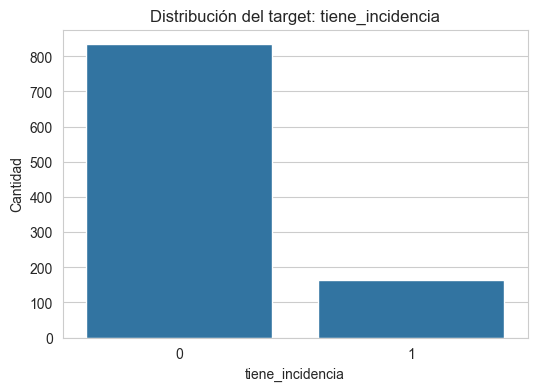


--- entrega_tardia ---
entrega_tardia
1    998
Name: count, dtype: int64
entrega_tardia
1    100.0
Name: proportion, dtype: float64


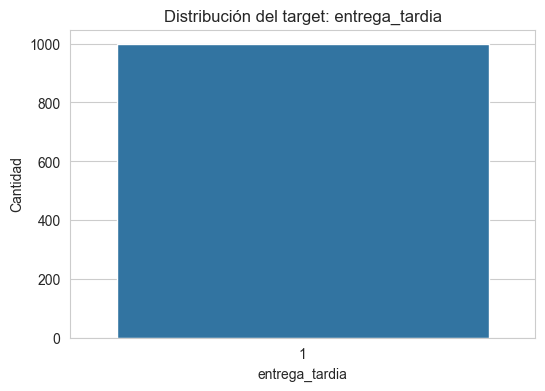


--- entrega_tardia_v3 ---
entrega_tardia_v3
1    925
0     73
Name: count, dtype: int64
entrega_tardia_v3
1    92.685371
0     7.314629
Name: proportion, dtype: float64


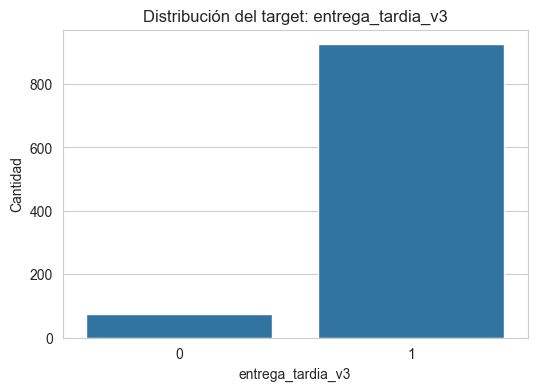


--- incidencia_multiclase ---
incidencia_multiclase
0    834
1    153
2     11
Name: count, dtype: int64
incidencia_multiclase
0    83.567134
1    15.330661
2     1.102204
Name: proportion, dtype: float64


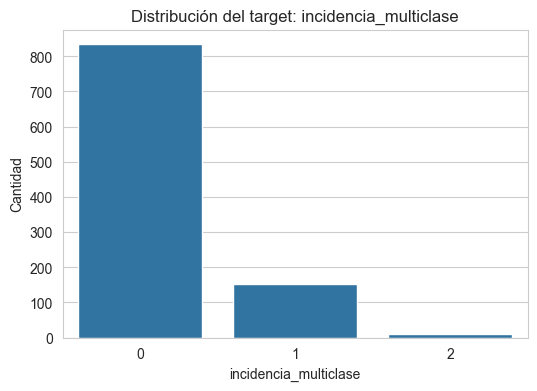


--- riesgo_operacional_alto ---
riesgo_operacional_alto
0    755
1    243
Name: count, dtype: int64
riesgo_operacional_alto
0    75.651303
1    24.348697
Name: proportion, dtype: float64


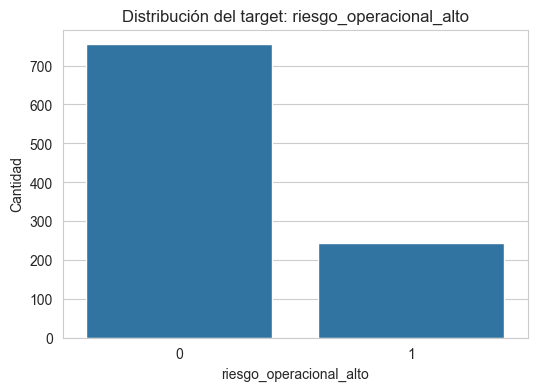


4. VARIABLES USADAS
Cantidad: 32
['distancia_km', 'tiempo_estimado_hrs', 'peso_kg', 'volumen_m3', 'capacidad_kg', 'capacidad_m3', 'velocidad_promedio_km_h', 'km_recorridos', 'tipo_via', 'tipo_carga', 'estado_vehiculo', 'tipo', 'uso_capacidad_kg', 'uso_capacidad_m3', 'uso_capacidad_kg_recalculado', 'uso_capacidad_m3_recalculado', 'antiguedad_vehiculo', 'densidad_carga', 'riesgo_velocidad', 'vehiculo_exigido', 'sobrecarga_kg', 'ruta_larga', 'velocidad_alta', 'vehiculo_riesgoso_estado', 'via_compleja', 'peso_kg_log', 'distancia_km_log', 'volumen_m3_log', 'velocidad_promedio_km_h_log', 'densidad_carga_log', 'riesgo_velocidad_log', 'km_recorridos_log']

5. RESULTADOS DE CLASIFICACIÓN


================ TARGET: tiene_incidencia ================


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,observacion
1,tiene_incidencia,Decision Tree,0.495,0.490927,0.160000,0.484848,0.240602,Modelado correctamente
4,tiene_incidencia,SVM,0.585,0.496189,0.162162,0.363636,0.224299,Modelado correctamente
5,tiene_incidencia,Gaussian NB,0.785,0.543005,0.272727,0.181818,0.218182,Modelado correctamente
3,tiene_incidencia,KNN,0.805,0.530666,0.285714,0.121212,0.170213,Modelado correctamente
0,tiene_incidencia,Logistic Regression,0.540,0.432771,0.116883,0.272727,0.163636,Modelado correctamente
2,tiene_incidencia,Random Forest,0.800,0.503357,0.181818,0.060606,0.090909,Modelado correctamente




================ TARGET: entrega_tardia ================

⚠️ El target 'entrega_tardia' no se puede modelar porque tiene una sola clase.
Distribución:
entrega_tardia
1    998
Name: count, dtype: int64


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,observacion
0,entrega_tardia,No modelable,NaN,NaN,NaN,NaN,NaN,Target con una sola clase




================ TARGET: entrega_tardia_v3 ================


...


6. TABLA FINAL DE CLASIFICACIÓN


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,observacion
7,entrega_tardia_v3,KNN,0.925,0.500000,0.925000,1.000000,0.961039,Modelado correctamente
19,riesgo_operacional_alto,Random Forest,0.980,0.979862,0.941176,0.979592,0.960000,Modelado correctamente
8,entrega_tardia_v3,Random Forest,0.920,0.497297,0.924623,0.994595,0.958333,Modelado correctamente
20,riesgo_operacional_alto,Decision Tree,0.965,0.963036,0.903846,0.959184,0.930693,Modelado correctamente
21,riesgo_operacional_alto,Logistic Regression,0.945,0.956683,0.827586,0.979592,0.897196,Modelado correctamente
9,entrega_tardia_v3,SVM,0.805,0.465766,0.919540,0.864865,0.891365,Modelado correctamente
22,riesgo_operacional_alto,SVM,0.935,0.943168,0.810345,0.959184,0.878505,Modelado correctamente
23,riesgo_operacional_alto,KNN,0.925,0.908974,0.826923,0.877551,0.851485,Modelado correctamente
24,riesgo_operacional_alto,Gaussian NB,0.900,0.926882,0.716418,0.979592,0.827586,Modelado correctamente
10,entrega_tardia_v3,Gaussian NB,0.640,0.468468,0.918519,0.670270,0.775000,Modelado correctamente



7. MEJOR MODELO POR TARGET


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,observacion
7,entrega_tardia_v3,KNN,0.925,0.500000,0.925000,1.000000,0.961039,Modelado correctamente
19,riesgo_operacional_alto,Random Forest,0.980,0.979862,0.941176,0.979592,0.960000,Modelado correctamente
13,incidencia_multiclase,KNN,0.815,0.351619,0.749658,0.815000,0.771142,Modelado correctamente
0,tiene_incidencia,Decision Tree,0.495,0.490927,0.160000,0.484848,0.240602,Modelado correctamente



8. MEJOR CLASIFICACIÓN GLOBAL
Target ganador: entrega_tardia_v3
Modelo ganador: KNN


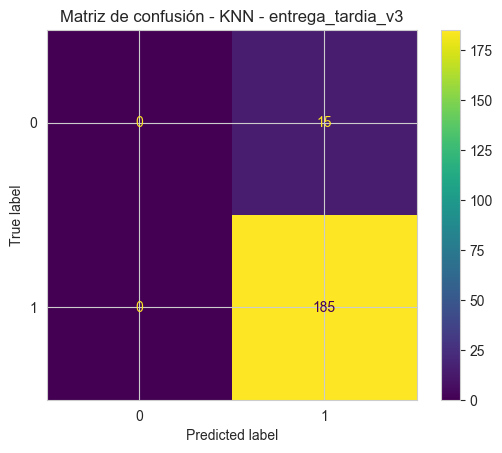


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.93      1.00      0.96       185

    accuracy                           0.93       200
   macro avg       0.46      0.50      0.48       200
weighted avg       0.86      0.93      0.89       200


9. RESULTADOS DE REGRESIÓN - riesgo_operacional


,target,modelo,mae,rmse,r2
2,riesgo_operacional,Random Forest Regressor,59.073087,131.484784,0.994829
1,riesgo_operacional,Decision Tree Regressor,203.751751,334.747512,0.966485
3,riesgo_operacional,KNN Regressor,453.218417,662.694984,0.868650
0,riesgo_operacional,Linear Regression,703.553530,1092.918625,0.642744
4,riesgo_operacional,SVR,1130.853390,1870.599274,-0.046562



10. MEJOR REGRESIÓN
Mejor modelo regresión: Random Forest Regressor


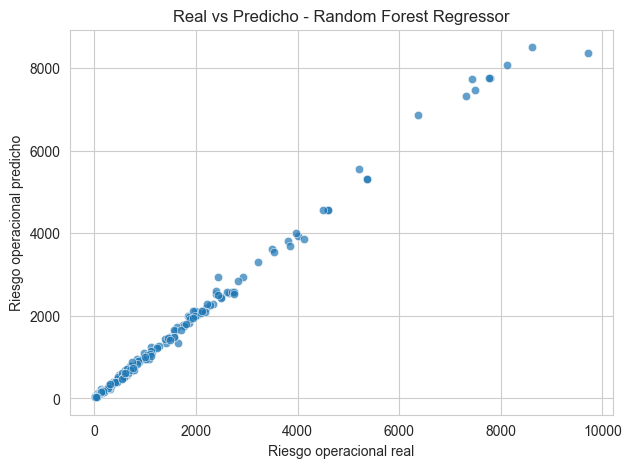

,Real,Predicción
0,8128.500000,8070.800643
1,6359.600000,6861.645231
2,372.049662,391.073291
3,874.370650,890.581552
4,1746.921410,1772.632872
5,2332.587290,2281.709692
6,49.100064,74.246619
7,604.078135,676.225336
8,128.747382,131.091177
9,317.646684,325.597231



11. RESUMEN FINAL
Mejor clasificación global:



target                    entrega_tardia_v3
modelo                                  KNN
accuracy                              0.925
balanced_accuracy                       0.5
precision                             0.925
recall                                  1.0
f1_score                           0.961039
observacion          Modelado correctamente
Name: 7, dtype: object


Mejor regresión:



target         riesgo_operacional
modelo    Random Forest Regressor
mae                     59.073087
rmse                   131.484784
r2                       0.994829
Name: 2, dtype: object


Mejores clasificaciones por target:


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,observacion
7,entrega_tardia_v3,KNN,0.925,0.500000,0.925000,1.000000,0.961039,Modelado correctamente
19,riesgo_operacional_alto,Random Forest,0.980,0.979862,0.941176,0.979592,0.960000,Modelado correctamente
13,incidencia_multiclase,KNN,0.815,0.351619,0.749658,0.815000,0.771142,Modelado correctamente
0,tiene_incidencia,Decision Tree,0.495,0.490927,0.160000,0.484848,0.240602,Modelado correctamente


In [2]:
# ============================================================
# RESULTADOS PARA 02_TARGET_SELECTION_AND_PROBLEM_DEFINITION
# VERSIÓN CORREGIDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# ============================================================
# 1. CARGA DATASET
# ============================================================

df = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

print("============================================================")
print("1. DATASET")
print("============================================================")
print("Dimensiones:", df.shape)

# ============================================================
# 2. CREACIÓN / VERIFICACIÓN DE TARGETS
# ============================================================

df["tiene_incidencia"] = df["tiene_incidencia"].astype(int)

if "entrega_tardia" in df.columns:
    df["entrega_tardia"] = df["entrega_tardia"].astype(int)
else:
    df["entrega_tardia"] = np.where(df["dias_entrega"] > 7, 1, 0)

percentil_entrega = df["dias_entrega"].quantile(0.75)

df["entrega_tardia_v3"] = np.where(
    df["dias_entrega"] >= percentil_entrega,
    1,
    0
)

df["incidencia_multiclase"] = np.select(
    [
        df["cantidad_incidencias"] == 0,
        df["cantidad_incidencias"] == 1,
        df["cantidad_incidencias"] >= 2
    ],
    [0, 1, 2],
    default=0
)

percentil_riesgo = df["riesgo_operacional"].quantile(0.75)

df["riesgo_operacional_alto"] = np.where(
    df["riesgo_operacional"] >= percentil_riesgo,
    1,
    0
)

print("\n============================================================")
print("2. UMBRALES USADOS")
print("============================================================")
print("Percentil 75 dias_entrega:", percentil_entrega)
print("Percentil 75 riesgo_operacional:", percentil_riesgo)

# ============================================================
# 3. DISTRIBUCIÓN DE TARGETS
# ============================================================

targets_clasificacion = [
    "tiene_incidencia",
    "entrega_tardia",
    "entrega_tardia_v3",
    "incidencia_multiclase",
    "riesgo_operacional_alto"
]

print("\n============================================================")
print("3. DISTRIBUCIÓN DE TARGETS")
print("============================================================")

for target in targets_clasificacion:
    print(f"\n--- {target} ---")
    print(df[target].value_counts(dropna=False))
    print(df[target].value_counts(normalize=True, dropna=False) * 100)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target)
    plt.title(f"Distribución del target: {target}")
    plt.xlabel(target)
    plt.ylabel("Cantidad")
    plt.show()

# ============================================================
# 4. VARIABLES PREDICTORAS
# ============================================================

variables_base = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo",
    "tipo",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",
    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "vehiculo_riesgoso_estado",
    "via_compleja",
    "peso_kg_log",
    "distancia_km_log",
    "volumen_m3_log",
    "velocidad_promedio_km_h_log",
    "densidad_carga_log",
    "riesgo_velocidad_log",
    "km_recorridos_log"
]

variables_modelo = [col for col in variables_base if col in df.columns]

print("\n============================================================")
print("4. VARIABLES USADAS")
print("============================================================")
print("Cantidad:", len(variables_modelo))
print(variables_modelo)

# ============================================================
# 5. PREPROCESAMIENTO
# ============================================================

def crear_preprocesador(X):
    variables_numericas = X.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    transformador_numerico = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    transformador_categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocesador = ColumnTransformer([
        ("num", transformador_numerico, variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ])

    return preprocesador

# ============================================================
# 6. FUNCIÓN CLASIFICACIÓN CORREGIDA
# ============================================================

def evaluar_clasificacion(target):

    datos = df[variables_modelo + [target]].dropna(subset=[target]).copy()

    X = datos[variables_modelo]
    y = datos[target]

    # Si el target tiene una sola clase, no se puede entrenar.
    if y.nunique() < 2:
        print(f"\n⚠️ El target '{target}' no se puede modelar porque tiene una sola clase.")
        print("Distribución:")
        print(y.value_counts())

        tabla_no_modelable = pd.DataFrame([{
            "target": target,
            "modelo": "No modelable",
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1_score": np.nan,
            "observacion": "Target con una sola clase"
        }])

        return tabla_no_modelable, None

    stratify_y = y if y.value_counts().min() >= 2 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=stratify_y
    )

    preprocesador = crear_preprocesador(X)

    modelos = {
        "Logistic Regression": LogisticRegression(
            random_state=42,
            max_iter=3000,
            class_weight="balanced"
        ),
        "Decision Tree": DecisionTreeClassifier(
            random_state=42,
            max_depth=6,
            class_weight="balanced"
        ),
        "Random Forest": RandomForestClassifier(
            random_state=42,
            n_estimators=200,
            max_depth=8,
            class_weight="balanced"
        ),
        "KNN": KNeighborsClassifier(),
        "SVM": SVC(
            random_state=42,
            class_weight="balanced"
        ),
        "Gaussian NB": GaussianNB()
    }

    resultados = []

    for nombre, modelo in modelos.items():

        pipe = Pipeline([
            ("preprocesamiento", preprocesador),
            ("modelo", modelo)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        promedio = "weighted" if y.nunique() > 2 else "binary"

        resultados.append({
            "target": target,
            "modelo": nombre,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average=promedio, zero_division=0),
            "recall": recall_score(y_test, y_pred, average=promedio, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, average=promedio, zero_division=0),
            "observacion": "Modelado correctamente"
        })

    tabla = pd.DataFrame(resultados).sort_values(by="f1_score", ascending=False)

    mejor_modelo_nombre = tabla.iloc[0]["modelo"]

    pipe_final = Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", modelos[mejor_modelo_nombre])
    ])

    pipe_final.fit(X_train, y_train)
    y_pred_final = pipe_final.predict(X_test)

    mejor_info = {
        "target": target,
        "modelo": mejor_modelo_nombre,
        "pipeline": pipe_final,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred_final
    }

    return tabla, mejor_info

# ============================================================
# 7. EJECUTAR CLASIFICACIONES
# ============================================================

tablas_clasificacion = []
mejores_clasificacion = {}

print("\n============================================================")
print("5. RESULTADOS DE CLASIFICACIÓN")
print("============================================================")

for target in targets_clasificacion:
    print(f"\n\n================ TARGET: {target} ================")

    tabla, mejor_info = evaluar_clasificacion(target)

    display(tabla)

    tablas_clasificacion.append(tabla)

    if mejor_info is not None:
        mejores_clasificacion[target] = mejor_info

tabla_clasificacion_final = pd.concat(
    tablas_clasificacion,
    ignore_index=True
)

print("\n============================================================")
print("6. TABLA FINAL DE CLASIFICACIÓN")
print("============================================================")

display(
    tabla_clasificacion_final.sort_values(
        by="f1_score",
        ascending=False,
        na_position="last"
    )
)

# ============================================================
# 8. MEJOR MODELO POR TARGET
# ============================================================

print("\n============================================================")
print("7. MEJOR MODELO POR TARGET")
print("============================================================")

tabla_modelables = tabla_clasificacion_final.dropna(subset=["f1_score"])

mejores_por_target = (
    tabla_modelables
    .sort_values(by="f1_score", ascending=False)
    .groupby("target")
    .head(1)
    .sort_values(by="f1_score", ascending=False)
)

display(mejores_por_target)

# ============================================================
# 9. MATRIZ Y REPORTE DEL MEJOR TARGET GLOBAL
# ============================================================

mejor_global = tabla_modelables.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

target_ganador = mejor_global["target"]
modelo_ganador = mejor_global["modelo"]

print("\n============================================================")
print("8. MEJOR CLASIFICACIÓN GLOBAL")
print("============================================================")
print("Target ganador:", target_ganador)
print("Modelo ganador:", modelo_ganador)

info = mejores_clasificacion[target_ganador]

matriz = confusion_matrix(info["y_test"], info["y_pred"])

disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot()
plt.title(f"Matriz de confusión - {modelo_ganador} - {target_ganador}")
plt.show()

print("\nClassification Report:")
print(
    classification_report(
        info["y_test"],
        info["y_pred"],
        zero_division=0
    )
)

# ============================================================
# 10. REGRESIÓN - RIESGO OPERACIONAL
# ============================================================

print("\n============================================================")
print("9. RESULTADOS DE REGRESIÓN - riesgo_operacional")
print("============================================================")

target_reg = "riesgo_operacional"

datos_reg = df[variables_modelo + [target_reg]].dropna(subset=[target_reg]).copy()

X = datos_reg[variables_modelo]
y = datos_reg[target_reg]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

preprocesador = crear_preprocesador(X)

modelos_reg = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(
        random_state=42,
        max_depth=6
    ),
    "Random Forest Regressor": RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=8
    ),
    "KNN Regressor": KNeighborsRegressor(),
    "SVR": SVR()
}

resultados_reg = []

for nombre, modelo in modelos_reg.items():

    pipe = Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", modelo)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    resultados_reg.append({
        "target": target_reg,
        "modelo": nombre,
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": rmse,
        "r2": r2_score(y_test, y_pred)
    })

tabla_regresion = pd.DataFrame(resultados_reg).sort_values(
    by="rmse",
    ascending=True
)

display(tabla_regresion)

# ============================================================
# 11. GRÁFICO REAL VS PREDICHO MEJOR REGRESIÓN
# ============================================================

mejor_reg_nombre = tabla_regresion.iloc[0]["modelo"]

print("\n============================================================")
print("10. MEJOR REGRESIÓN")
print("============================================================")
print("Mejor modelo regresión:", mejor_reg_nombre)

modelo_mejor_reg = modelos_reg[mejor_reg_nombre]

pipe_mejor_reg = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", modelo_mejor_reg)
])

pipe_mejor_reg.fit(X_train, y_train)
y_pred_reg = pipe_mejor_reg.predict(X_test)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred_reg, alpha=0.7)
plt.title(f"Real vs Predicho - {mejor_reg_nombre}")
plt.xlabel("Riesgo operacional real")
plt.ylabel("Riesgo operacional predicho")
plt.show()

comparacion_reg = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": y_pred_reg
}).head(15)

display(comparacion_reg)

# ============================================================
# 12. RESUMEN FINAL PARA NOTEBOOK 02
# ============================================================

print("\n============================================================")
print("11. RESUMEN FINAL")
print("============================================================")

print("Mejor clasificación global:")
display(mejor_global)

print("\nMejor regresión:")
display(tabla_regresion.iloc[0])

print("\nMejores clasificaciones por target:")
display(mejores_por_target)


## Índice del notebook

Puedes navegar por las secciones desde el panel lateral de Jupyter o usando los encabezados principales:

- [1. Configuración inicial](#1-configuración-inicial)
- [2. Carga del dataset final](#2-carga-del-dataset-final)
- [3. EDA general del dataset](#3-eda-general-del-dataset)
- [4. Análisis visual logístico](#4-análisis-visual-logístico)
- [5. Enfoque del problema predictivo](#5-enfoque-del-problema-predictivo)
- [6. Conclusiones del análisis exploratorio](#6-conclusiones-del-análisis-exploratorio)



# 1. Configuración inicial

En esta sección se cargan las librerías necesarias y se conecta el notebook con el proyecto Kedro.


In [1]:

%load_ext kedro.ipython

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython



# 2. Carga del dataset final

El dataset utilizado corresponde a la salida final del flujo Kedro:

`data/05_model_input/dataset_modelo.csv`

Este archivo se utiliza porque ya contiene los datos limpios, integrados, validados y con variables derivadas creadas durante el pipeline de transformación.


In [2]:

df = catalog.load("dataset_modelo")

df.head()


[05/07/26 16:41:09] INFO     Loading data from dataset_modelo (CSVDataset)...                  ]8;id=6603222;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=6603223;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia
0,1.00,2023-01-01,39.00,46.00,"12,675.80",28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.30,16.70,urbana,"1,950.00",ouuc-52,camión,"10,000.00",20.50,"2,022.00",en mantención,"17,043.00",0.00,0.00,sin incidencia,0.00,4.00,55.05,1.27,1.39,1
1,2.00,NaN,3.00,27.00,13.60,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.60,18.40,urbana,"2,447.00",fgkf-38,van,"1,000.00",22.10,"2,010.00",operativo,"88,004.00",0.00,0.00,sin incidencia,0.00,7.00,36.93,0.01,1.13,1
2,3.00,2023-01-02,73.00,18.00,"2,536.00",50.55,refrigerada,entregado,NaN,maipú,san antonio,468.40,5.20,ruta nacional,"11,768.00",agdn-22,furgón,"20,000.00",38.90,"2,023.00",en mantención,"243,705.00",0.00,0.00,sin incidencia,0.00,7.00,90.08,0.13,1.30,1
3,4.00,2023-01-03,49.00,45.00,466.00,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,"1,642.40",18.90,ruta nacional,"7,202.00",ialh-88,van,"1,000.00",25.30,"2,015.00",operativo,"224,573.50",1.00,"1,747,372.00",desvío de ruta,1.00,4.00,86.90,0.47,0.55,1
4,5.00,NaN,17.00,36.00,"4,928.90",0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,"1,556.60",17.90,urbana,"3,799.00",glfy-29,camioneta,"5,000.00",49.10,"2,023.00",operativo,"138,259.00",0.00,0.00,sin incidencia,0.00,7.00,86.96,0.99,0.01,1



El dataset cargado corresponde a la base final del proyecto. A diferencia de los archivos originales, este dataset ya integra información de envíos, rutas, vehículos e incidencias.



# 3. EDA general del dataset

Esta sección resume la estructura general del dataset final y permite revisar dimensiones, tipos de datos, valores nulos y estadísticas descriptivas.



## 3.1 Dimensiones del dataset


In [3]:

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")


Filas: 1030
Columnas: 31



## 3.2 Tipos de datos


In [4]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_envio                   1030 non-null   float64
 1   fecha_envio                478 non-null    object 
 2   id_ruta                    1030 non-null   float64
 3   id_vehiculo                1030 non-null   float64
 4   peso_kg                    1030 non-null   float64
 5   volumen_m3                 1030 non-null   float64
 6   tipo_carga                 1030 non-null   object 
 7   estado                     1030 non-null   object 
 8   fecha_entrega              479 non-null    object 
 9   origen                     1002 non-null   object 
 10  destino                    1002 non-null   object 
 11  distancia_km               1002 non-null   float64
 12  tiempo_estimado_hrs        1002 non-null   float64
 13  tipo_via                   1002 non-null   objec


## 3.3 Estadísticas descriptivas


In [5]:

df.describe().T


,count,mean,std,min,25%,50%,75%,max
id_envio,"1,030.00",505.77,281.75,1.00,271.25,504.50,744.75,"1,000.00"
id_ruta,"1,030.00",39.55,22.26,1.00,21.00,39.00,58.00,80.00
id_vehiculo,"1,030.00",29.97,17.26,1.00,15.00,29.00,45.00,60.00
peso_kg,"1,030.00","10,887.28","40,728.86","-66,657.50","3,802.35","7,558.60","11,245.38","724,190.00"
volumen_m3,"1,030.00",30.47,16.89,0.11,16.53,30.30,45.09,59.96
distancia_km,"1,002.00","1,302.53","2,467.81",29.60,507.20,919.30,"1,492.80","18,627.00"
tiempo_estimado_hrs,"1,002.00",12.30,6.65,0.90,6.30,12.20,17.50,23.70
peaje_total,"1,002.00","6,775.98","4,435.93",68.00,"2,453.00","6,641.00","10,474.00","14,941.00"
capacidad_kg,999.00,"7,589.59","5,918.09","1,000.00","3,000.00","5,000.00","10,000.00","20,000.00"
capacidad_m3,999.00,36.54,20.26,5.30,18.50,38.10,49.20,78.90



## 3.4 Valores nulos


In [6]:

nulos = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

nulos[nulos > 0]



fecha_envio            552
fecha_entrega          551
año_fabricacion         31
capacidad_m3            31
capacidad_kg            31
tipo                    31
placa                   31
estado_vehiculo         31
km_recorridos           31
peaje_total             28
tiempo_estimado_hrs     28
distancia_km            28
destino                 28
origen                  28
tipo_via                28
dtype: int64


### Análisis

El análisis de valores nulos permite identificar columnas que todavía podrían requerir tratamiento adicional antes de entrenar modelos.  
Sin embargo, las variables principales generadas para modelado, como `entrega_tardia`, `dias_entrega`, `cantidad_incidencias` y `uso_capacidad_kg`, deben encontrarse completas para permitir la etapa de Machine Learning.



## 3.5 Revisión de variables principales


In [7]:

variables_principales = [
    "peso_kg",
    "volumen_m3",
    "distancia_km",
    "tiempo_estimado_hrs",
    "capacidad_kg",
    "capacidad_m3",
    "dias_entrega",
    "entrega_tardia",
    "cantidad_incidencias",
    "tiene_incidencia",
    "uso_capacidad_kg",
    "velocidad_promedio_km_h"
]

df[variables_principales].head()


,peso_kg,volumen_m3,distancia_km,tiempo_estimado_hrs,capacidad_kg,capacidad_m3,dias_entrega,entrega_tardia,cantidad_incidencias,tiene_incidencia,uso_capacidad_kg,velocidad_promedio_km_h
0,"12,675.80",28.48,919.30,16.70,"10,000.00",20.50,4.00,1,0.00,0.00,1.27,55.05
1,13.60,24.93,679.60,18.40,"1,000.00",22.10,7.00,1,0.00,0.00,0.01,36.93
2,"2,536.00",50.55,468.40,5.20,"20,000.00",38.90,7.00,1,0.00,0.00,0.13,90.08
3,466.00,13.88,"1,642.40",18.90,"1,000.00",25.30,4.00,1,1.00,1.00,0.47,86.90
4,"4,928.90",0.44,"1,556.60",17.90,"5,000.00",49.10,7.00,1,0.00,0.00,0.99,86.96



## 3.6 Distribución de la variable objetivo de clasificación


In [8]:

conteo_entrega = df["entrega_tardia"].value_counts().sort_index()
porcentaje_entrega = df["entrega_tardia"].value_counts(normalize=True).sort_index() * 100

resumen_entrega = pd.DataFrame({
    "cantidad": conteo_entrega,
    "porcentaje": porcentaje_entrega
})

resumen_entrega


,cantidad,porcentaje
entrega_tardia,,
0,28,2.72
1,1002,97.28


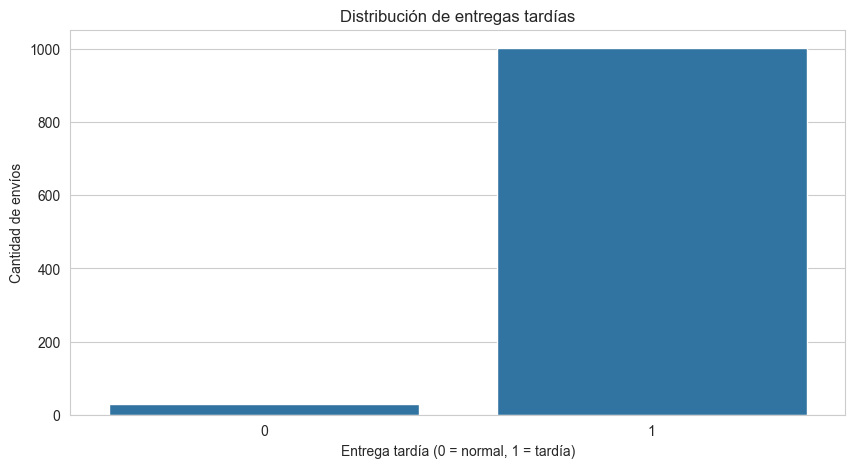

In [9]:

sns.countplot(data=df, x="entrega_tardia")

plt.title("Distribución de entregas tardías")
plt.xlabel("Entrega tardía (0 = normal, 1 = tardía)")
plt.ylabel("Cantidad de envíos")

plt.show()



### Análisis

La variable `entrega_tardia` permite transformar el problema logístico en un problema de clasificación.  
Su distribución es relevante porque permite observar si existe desbalance entre entregas normales y tardías, aspecto que posteriormente puede influir en la selección de métricas y modelos.



## 3.7 Distribución de días de entrega


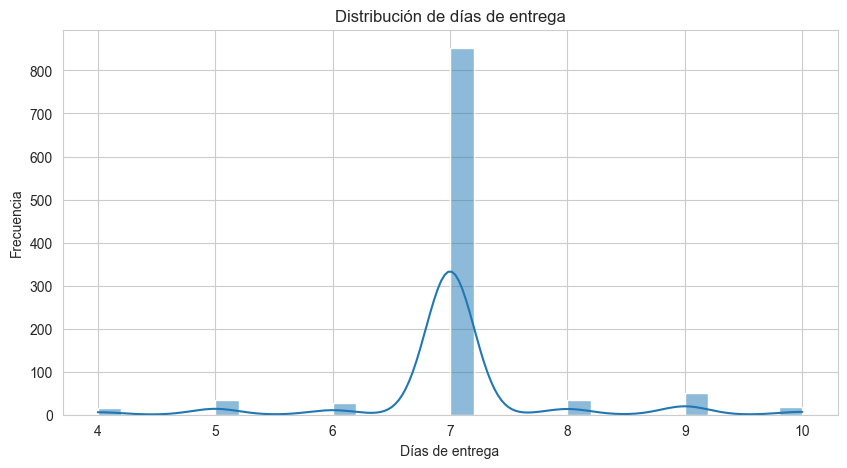

In [10]:

sns.histplot(df["dias_entrega"], bins=30, kde=True)

plt.title("Distribución de días de entrega")
plt.xlabel("Días de entrega")
plt.ylabel("Frecuencia")

plt.show()



### Análisis

La variable `dias_entrega` representa una posible variable objetivo para modelos de regresión, ya que permite estimar numéricamente la duración de una entrega.



## 3.8 Correlación entre variables numéricas


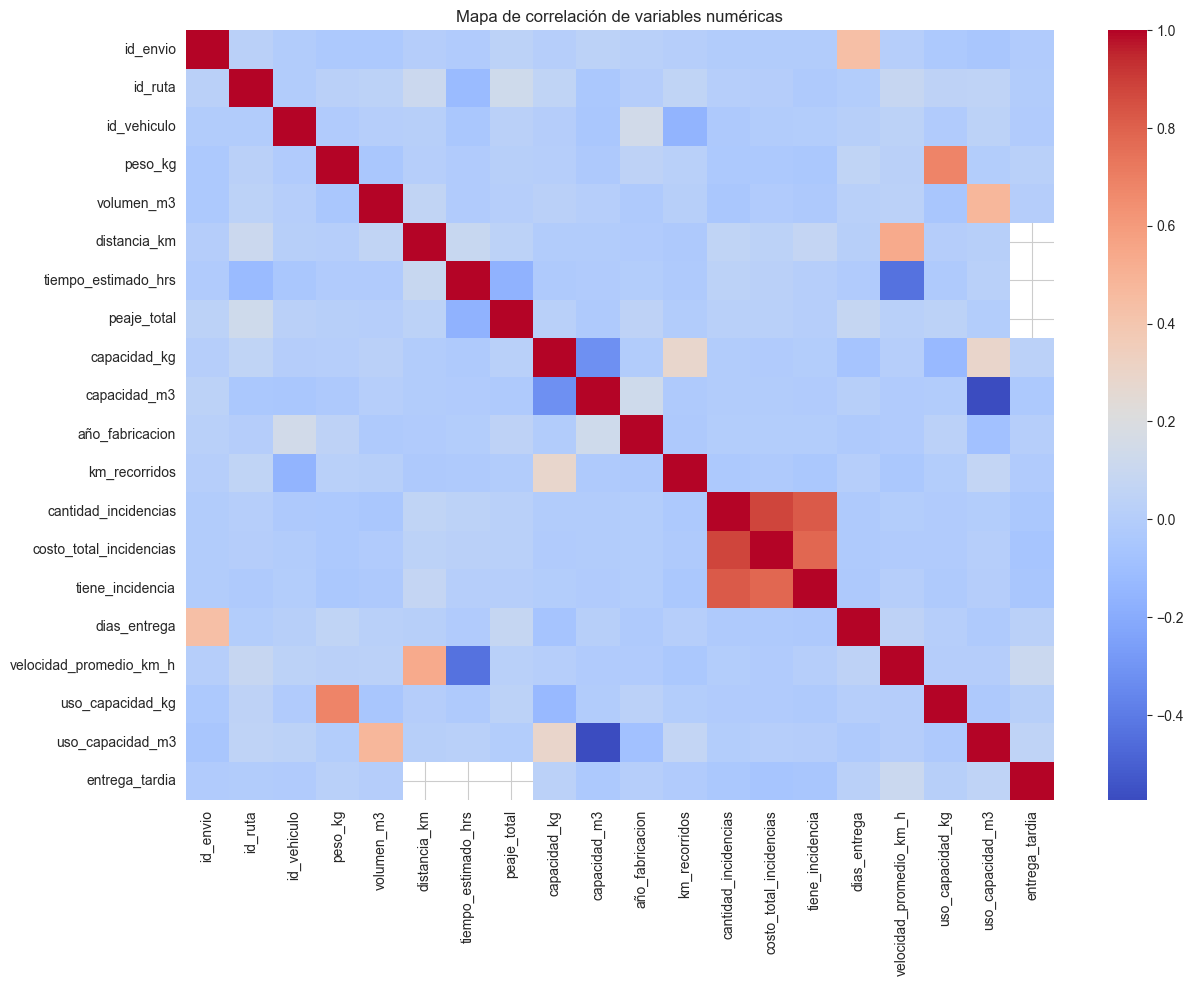

In [11]:

columnas_numericas = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))
sns.heatmap(columnas_numericas.corr(), cmap="coolwarm", annot=False)

plt.title("Mapa de correlación de variables numéricas")
plt.show()



### Análisis

El mapa de correlación permite identificar relaciones entre variables numéricas.  
Este paso ayuda a reconocer variables que podrían aportar información relevante para los modelos predictivos y también permite detectar posibles redundancias.



# 4. Análisis visual logístico

Esta sección profundiza en patrones relacionados con rutas, vehículos, incidencias, capacidad y retrasos.  
El objetivo es detectar relaciones útiles para la interpretación del negocio y para la futura selección de variables en los modelos.



## 4.1 Distancia recorrida según entrega tardía


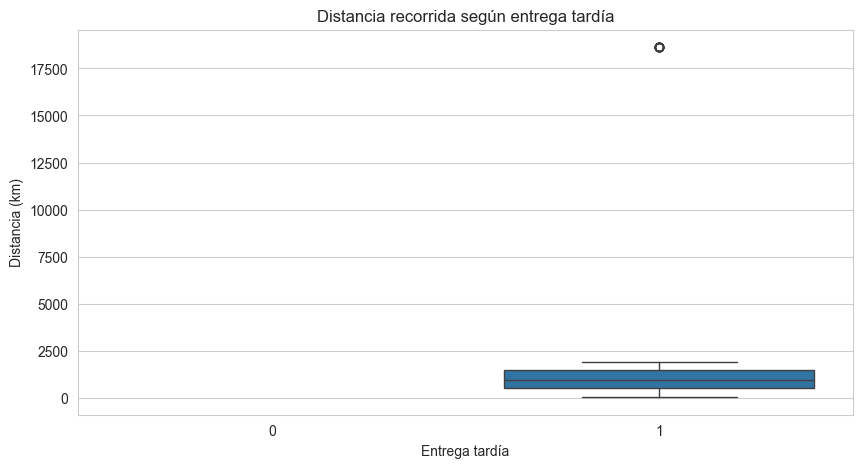

In [12]:

sns.boxplot(data=df, x="entrega_tardia", y="distancia_km")

plt.title("Distancia recorrida según entrega tardía")
plt.xlabel("Entrega tardía")
plt.ylabel("Distancia (km)")

plt.show()



### Análisis

Este gráfico permite observar si los envíos tardíos presentan una distribución distinta en la distancia recorrida.  
Si los envíos tardíos concentran distancias mayores o una mayor dispersión, la distancia podría ser una variable relevante para el modelado.



## 4.2 Peso del envío según entrega tardía


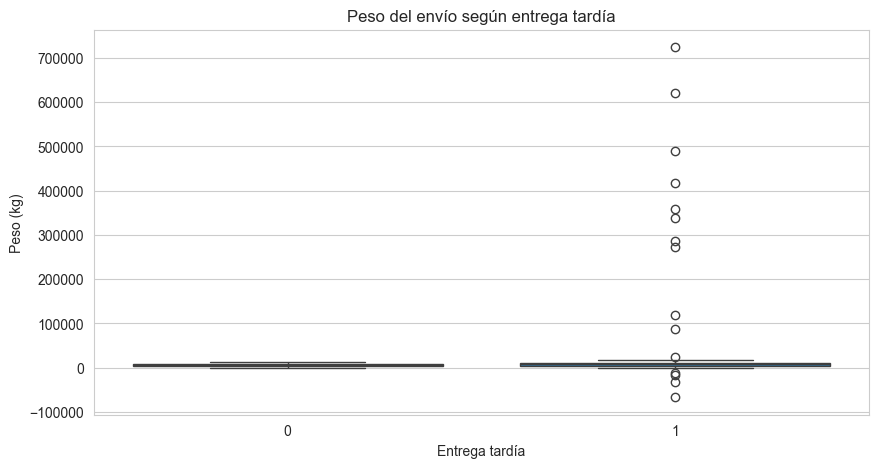

In [13]:

sns.boxplot(data=df, x="entrega_tardia", y="peso_kg")

plt.title("Peso del envío según entrega tardía")
plt.xlabel("Entrega tardía")
plt.ylabel("Peso (kg)")

plt.show()



### Análisis

El peso del envío puede afectar la planificación logística, especialmente cuando se relaciona con la capacidad disponible del vehículo.



## 4.3 Uso de capacidad del vehículo


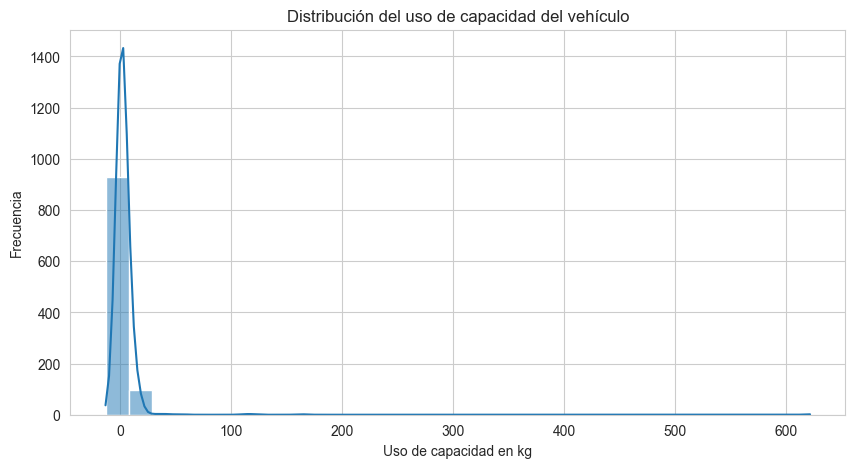

In [14]:

sns.histplot(df["uso_capacidad_kg"], bins=30, kde=True)

plt.title("Distribución del uso de capacidad del vehículo")
plt.xlabel("Uso de capacidad en kg")
plt.ylabel("Frecuencia")

plt.show()



### Análisis

El uso de capacidad permite evaluar qué tan aprovechados se encuentran los vehículos.  
Valores muy altos podrían indicar operaciones con mayor exigencia logística.



## 4.4 Uso de capacidad según entrega tardía


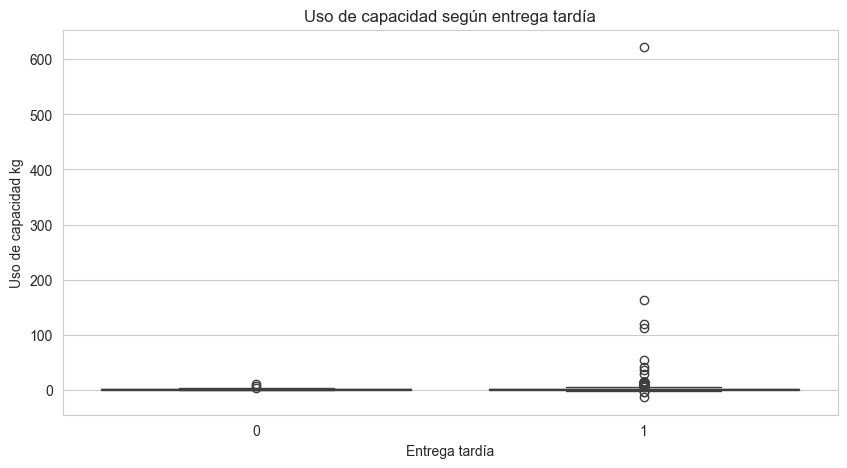

In [15]:

sns.boxplot(data=df, x="entrega_tardia", y="uso_capacidad_kg")

plt.title("Uso de capacidad según entrega tardía")
plt.xlabel("Entrega tardía")
plt.ylabel("Uso de capacidad kg")

plt.show()



### Análisis

Este gráfico permite revisar si los envíos tardíos tienen un comportamiento distinto en el nivel de uso de capacidad del vehículo.



## 4.5 Incidencias por tipo de vehículo


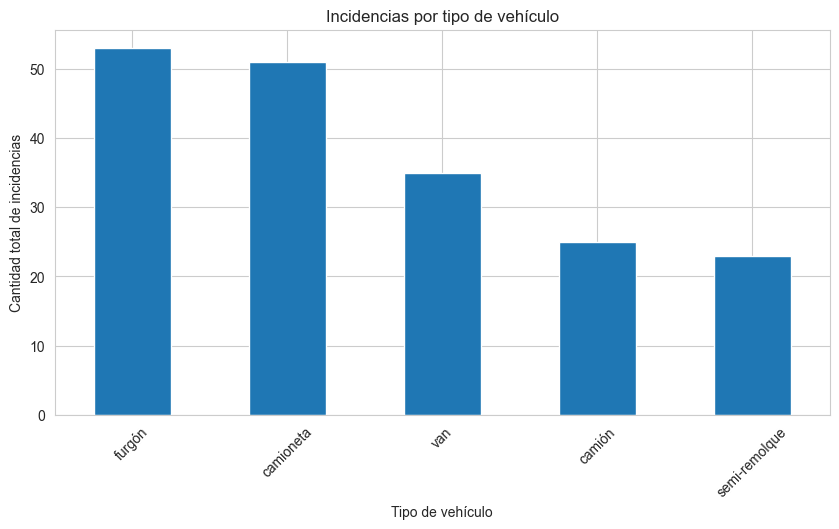

In [16]:

if "tipo" in df.columns:
    incidencias_tipo = (
        df.groupby("tipo")["cantidad_incidencias"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    incidencias_tipo.plot(kind="bar")

    plt.title("Incidencias por tipo de vehículo")
    plt.xlabel("Tipo de vehículo")
    plt.ylabel("Cantidad total de incidencias")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("La columna 'tipo' no está disponible en el dataset.")



### Análisis

El análisis por tipo de vehículo permite identificar si ciertos vehículos concentran más incidencias, lo que podría asociarse a mantenimiento, capacidad o uso operativo.



## 4.6 Rutas con más entregas tardías


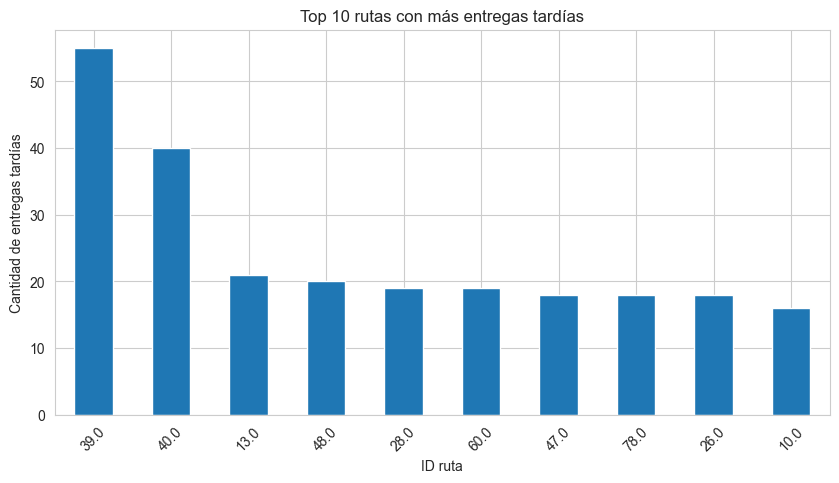

In [17]:

rutas_tardias = (
    df.groupby("id_ruta")["entrega_tardia"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

rutas_tardias.plot(kind="bar")

plt.title("Top 10 rutas con más entregas tardías")
plt.xlabel("ID ruta")
plt.ylabel("Cantidad de entregas tardías")
plt.xticks(rotation=45)

plt.show()



### Análisis

Este gráfico permite identificar rutas con mayor concentración de retrasos.  
Estas rutas podrían ser candidatas para revisión operacional o mejora en la planificación.



## 4.7 Costo total de incidencias


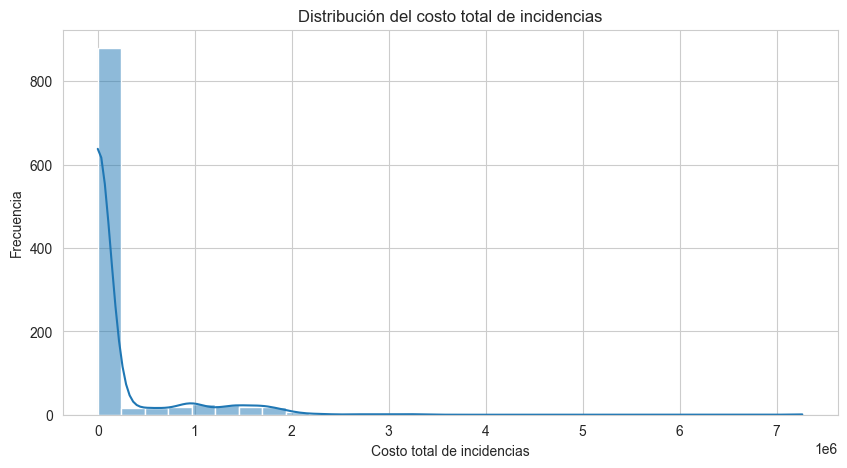

In [18]:

sns.histplot(df["costo_total_incidencias"], bins=30, kde=True)

plt.title("Distribución del costo total de incidencias")
plt.xlabel("Costo total de incidencias")
plt.ylabel("Frecuencia")

plt.show()



### Análisis

El costo total de incidencias permite identificar el impacto económico asociado a problemas durante el proceso logístico.



## 4.8 Velocidad promedio según entrega tardía


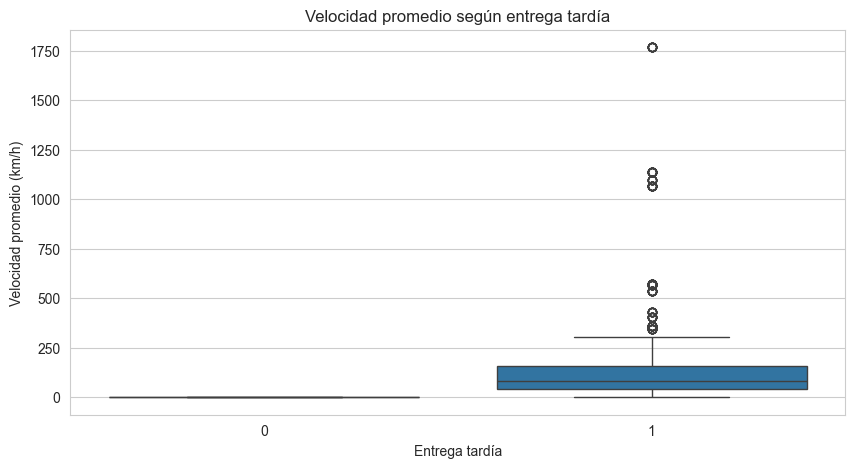

In [19]:

sns.boxplot(data=df, x="entrega_tardia", y="velocidad_promedio_km_h")

plt.title("Velocidad promedio según entrega tardía")
plt.xlabel("Entrega tardía")
plt.ylabel("Velocidad promedio (km/h)")

plt.show()



### Análisis

La velocidad promedio es una variable derivada que puede entregar información relevante sobre la eficiencia operacional de una ruta.



# 5. Enfoque del problema predictivo

En esta sección se define el enfoque de Machine Learning que se utilizará en los siguientes notebooks.  
Las instrucciones de la Evaluación 2 solicitan implementar modelos supervisados y no supervisados, evaluarlos, compararlos y justificar las decisiones técnicas. No se indica una variable objetivo específica, por lo que se debe proponer un enfoque coherente con el problema logístico.



## 5.1 ¿Por qué predecir entregas tardías?

La variable `entrega_tardia` representa un problema real para una empresa logística.  
Predecir si un envío podría llegar tarde permite tomar decisiones antes de que el problema ocurra.

Por ejemplo:

- Ajustar rutas.
- Reasignar vehículos.
- Informar anticipadamente al cliente.
- Priorizar envíos críticos.
- Reducir costos asociados a incumplimientos.

Por esta razón, `entrega_tardia` se propone como variable objetivo para un modelo de clasificación.


In [20]:

df["entrega_tardia"].value_counts()



entrega_tardia
1    1002
0      28
Name: count, dtype: int64


## 5.2 ¿Por qué predecir días de entrega?

La variable `dias_entrega` permite estimar numéricamente cuánto podría tardar una entrega.

Este enfoque responde a una pregunta distinta:

> ¿Cuántos días podría demorar un envío?

Por esta razón, `dias_entrega` se propone como variable objetivo para un modelo de regresión.


In [21]:

df["dias_entrega"].describe()



count   1,030.00
mean        7.04
std         0.82
min         4.00
25%         7.00
50%         7.00
75%         7.00
max        10.00
Name: dias_entrega, dtype: float64


## 5.3 Posibles variables predictoras

Las siguientes variables podrían utilizarse como entradas para los modelos, ya que representan información logística relevante:

- `distancia_km`
- `tiempo_estimado_hrs`
- `peso_kg`
- `volumen_m3`
- `capacidad_kg`
- `capacidad_m3`
- `cantidad_incidencias`
- `tiene_incidencia`
- `uso_capacidad_kg`
- `velocidad_promedio_km_h`

Estas variables serán revisadas con mayor detalle en los notebooks de modelado.


In [22]:

posibles_predictoras = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "cantidad_incidencias",
    "tiene_incidencia",
    "uso_capacidad_kg",
    "velocidad_promedio_km_h"
]

df[posibles_predictoras].head()


,distancia_km,tiempo_estimado_hrs,peso_kg,volumen_m3,capacidad_kg,capacidad_m3,cantidad_incidencias,tiene_incidencia,uso_capacidad_kg,velocidad_promedio_km_h
0,919.30,16.70,"12,675.80",28.48,"10,000.00",20.50,0.00,0.00,1.27,55.05
1,679.60,18.40,13.60,24.93,"1,000.00",22.10,0.00,0.00,0.01,36.93
2,468.40,5.20,"2,536.00",50.55,"20,000.00",38.90,0.00,0.00,0.13,90.08
3,"1,642.40",18.90,466.00,13.88,"1,000.00",25.30,1.00,1.00,0.47,86.90
4,"1,556.60",17.90,"4,928.90",0.44,"5,000.00",49.10,0.00,0.00,0.99,86.96



## 5.4 Precaución: fuga de información

Para entrenar modelos predictivos es importante evitar variables que entreguen información que solo estaría disponible después de finalizar el envío.

Por ejemplo, si se quiere predecir `entrega_tardia`, se debe tener cuidado con variables como:

- `fecha_entrega`
- `dias_entrega`

Estas variables pueden generar **data leakage**, es decir, fuga de información.  
En los siguientes notebooks se seleccionarán variables considerando qué información estaría disponible antes o durante la planificación logística.



# 6. Conclusiones del análisis exploratorio

A partir del análisis exploratorio se identifican varios elementos relevantes para continuar con la Evaluación 2:

- El dataset final generado por Kedro está listo para análisis y modelado.
- La variable `entrega_tardia` permite plantear un problema de clasificación.
- La variable `dias_entrega` permite plantear un problema de regresión.
- Las variables logísticas derivadas, como `uso_capacidad_kg`, `velocidad_promedio_km_h` y `cantidad_incidencias`, aportan información útil para explicar el comportamiento de los envíos.
- Existen patrones asociados a rutas, vehículos, distancia e incidencias que justifican avanzar hacia modelos predictivos.

Con este notebook se cumple la etapa de análisis exploratorio, visualización y detección de patrones solicitada antes de implementar los modelos supervisados.
